# **📊 Pr. 3**

---

**Title:** Risk Alert Classifier

**Duration:** 6 Hours

---

## **🎯 Objective**

The objective of this project is to design, evaluate, and optimize a classification system that predicts high-risk customer behavior. Students will implement multiple classification algorithms, evaluate models using advanced classification metrics, handle imbalanced data, and improve performance using sampling techniques and hyperparameter tuning.

---

## **📑 Problem Statement**

You are working as a **Data Scientist** for a digital banking platform. The bank wants to build an **early-warning system** that identifies **high-risk customers** who are likely to default on payments or engage in fraudulent behavior.

The dataset contains customer demographic, behavioral, and transaction-related features. However, the dataset is **highly imbalanced**, where risky customers form a small minority.

Your task is to build a **robust classification pipeline** that:
- Accurately identifies high-risk customers
- Handles class imbalance effectively
- Evaluates performance using appropriate classification metrics
- Improves model accuracy using **hyperparameter tuning**

---

## **📚 Download and Import Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_curve, auc

---

## **🧠 Part A: Conceptual Foundation (Theory)**

Answer briefly (2–4 lines each):

1. What is **Logistic Regression** and why is it suitable for classification?
2. Explain **classification performance metrics** and why **accuracy** alone is insufficient.
3. Define **Type-I Error** and **Type-II Error** in the context of risk prediction.
4. Explain **Precision**, **Recall**, **F1-Score**, **TPR**, and **FPR**.
5. What is **AUC-ROC** and how does it help in evaluating classifiers?
6. Why does **imbalanced data** create problems in classification models?

Questions & Answers are written in the file named [`theory-concepts.pdf`](./theory-concepts.pdf) in the main directory.

---

## 🧪 **Part B: Dataset Understanding & Preparation**

You are provided with a dataset containing:

- Customer demographic information
- Transaction activity indicators
- Credit behavior indicators
- Target variable: **Risk Status**
  - `0` → Low Risk
  - `1` → High Risk

**Dataset:** [Access from here](.\data\Risk_Alert_Classifier_Dataset_4600.csv)

### Tasks:

7. Identify input features and target variable.
8. Perform a **train–test split** while maintaining class distribution.
9. Identify missing values and apply **KNN Imputer** for multivariate imputation.

In [2]:
data_path = r".\data\Risk_Alert_Classifier_Dataset_4600.csv"

df = pd.read_csv(data_path)

display(df.head())
print("---", end="\n\n")
display(df.info())
print("---", end="\n\n")
display(df.describe())
print("---", end="\n\n")
display(df.isnull().sum())

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


---

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   str    
 3   region                     4498 non-null   str    
 4   employment_type            4456 non-null   str    
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64  
 14

None

---



,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


---



customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [3]:
target_col = 'risk_status'
feature_cols = [col for col in df.columns if col not in ['customer_id', target_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()

if 'last_transaction_date' in X.columns:
    X['last_transaction_date'] = pd.to_datetime(X['last_transaction_date'], errors='coerce')
    X['last_transaction_date'] = (X['last_transaction_date'] - pd.Timestamp('1970-01-01')).dt.days

categorical_cols = X.select_dtypes(include=['str', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print('Input features:')
print(list(X.columns))
print('\nTarget variable:', target_col)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('\nClass distribution before split:')
print(y.value_counts(normalize=True))
print('\nClass distribution after split:')
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

print('\nMissing values before imputation:')
print(X.isnull().sum())

imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

print('\nShape of imputed training data:', X_train.shape)
print('Shape of imputed test data:', X_test.shape)
print('Missing values after imputation:', pd.isnull(X_train).sum().sum())

Input features:
['age', 'annual_income_inr', 'credit_score', 'credit_utilization_ratio', 'missed_payments_12m', 'avg_late_payment_days', 'monthly_transaction_count', 'monthly_spend_inr', 'cash_advance_count_6m', 'complaints_last_6m', 'failed_login_attempts_3m', 'account_tenure_months', 'last_transaction_date', 'debt_balance_inr', 'gender_Male', 'gender_Other', 'region_East', 'region_North', 'region_South', 'region_West', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed']

Target variable: risk_status

Class distribution before split:
risk_status
0    0.878913
1    0.121087
Name: proportion, dtype: float64

Class distribution after split:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64

Missing values before imputation:
age                              140
annual_income_inr                166
credit_score                    

---

## 📊 **Part C: Baseline Classification Model**

10. Implement **Logistic Regression** as a baseline model.
11. Generate and interpret:
    - Confusion Matrix
    - Accuracy Score
    - Precision, Recall, F1-Score
12. Identify **Type-I** and **Type-II** errors from the confusion matrix.

In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_pred_log_reg)
tn, fp, fn, tp = cm.ravel()

evaluation_metrics_log_reg = {
    "Confusion Matrix": cm,
    "Accuracy": accuracy_score(y_test, y_pred_log_reg),
    "Precision": precision_score(y_test, y_pred_log_reg, average='weighted'),
    "Recall": recall_score(y_test, y_pred_log_reg, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred_log_reg, average='weighted')
}

print("Confusion Matrix:\n", cm)
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")
print(f"Type-I Error (False Positive): {fp}")
print(f"Type-II Error (False Negative): {fn}")


Confusion Matrix:
 [[809   0]
 [  2 109]]
True Negatives: 809, False Positives: 0, False Negatives: 2, True Positives: 109
Type-I Error (False Positive): 0
Type-II Error (False Negative): 2


c:\Users\Prath\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

## ⚖️ **Part D: Handling Imbalanced Data**

13. Demonstrate the impact of class imbalance on model performance.

14. Apply the following techniques and retrain the model:
   - **Under-Sampling**
   - **Over-Sampling**
   - **SMOTE**
   - **ADASYN**

15. Compare performance before and after balancing using:
   - Recall for minority class
   - F1-Score
   - AUC-ROC

In [5]:
def evaluate_model_log_reg(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Recall (minority=1)": recall_score(y_test, y_pred, pos_label=1),
        "F1 Score (minority=1)": f1_score(y_test, y_pred, pos_label=1),
        "AUC-ROC": roc_auc_score(y_test, y_scores),
    }


strategies_imbalanced_data = {
    "Under-Sampled": RandomUnderSampler(random_state=42).fit_resample(X_train, y_train),
    "Over-Sampled": RandomOverSampler(random_state=42).fit_resample(X_train, y_train),
    "SMOTE": SMOTE(random_state=42).fit_resample(X_train, y_train),
    "ADASYN": ADASYN(random_state=42).fit_resample(X_train, y_train),
}

results_imbalanced_data = []
for name, (X_res, y_res) in strategies_imbalanced_data.items():
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_res, y_res)
    metrics = evaluate_model_log_reg(name, model, X_test, y_test)
    results_imbalanced_data.append(metrics)

results_df = pd.DataFrame(results_imbalanced_data).set_index("Model")
print("Comparison of models:\n")
print(results_df)

c:\Users\Prath\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Prath\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Comparison of models:

               Recall (minority=1)  F1 Score (minority=1)   AUC-ROC
Model                                                              
Under-Sampled             0.990991               0.964912  0.999822
Over-Sampled              1.000000               0.977974  0.999933
SMOTE                     1.000000               0.986667  0.999944
ADASYN                    1.000000               0.969432  0.999878


c:\Users\Prath\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
best_imbalanced_model_name = results_df["F1 Score (minority=1)"].idxmax()
best_imbalanced_model_metrics = results_df.loc[best_imbalanced_model_name]
print(f"Best imbalanced model: {best_imbalanced_model_name}")

Best imbalanced model: SMOTE


---

## 🌳 **Part E: Tree-Based Classification Models**

16. Implement **Decision Tree Classifier**.
17. Analyze overfitting by comparing training and testing performance.
18. Implement **Random Forest Classifier**.
19. Compare Decision Tree vs Random Forest in terms of accuracy and generalization.

In [7]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_train_dt = dt_model.predict(X_train)
y_test_dt = dt_model.predict(X_test)

dt_train_acc = accuracy_score(y_train, y_train_dt)
dt_test_acc = accuracy_score(y_test, y_test_dt)
dt_train_f1 = f1_score(y_train, y_train_dt, pos_label=1)
dt_test_f1 = f1_score(y_test, y_test_dt, pos_label=1)
dt_gap = dt_train_acc - dt_test_acc

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_train_rf = rf_model.predict(X_train)
y_test_rf = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, y_train_rf)
rf_test_acc = accuracy_score(y_test, y_test_rf)
rf_train_f1 = f1_score(y_train, y_train_rf, pos_label=1)
rf_test_f1 = f1_score(y_test, y_test_rf, pos_label=1)
rf_gap = rf_train_acc - rf_test_acc

comparison_df = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Train Accuracy": dt_train_acc,
        "Test Accuracy": dt_test_acc,
        "Train F1": dt_train_f1,
        "Test F1": dt_test_f1,
        "Generalization Gap": dt_gap,
    },
    {
        "Model": "Random Forest",
        "Train Accuracy": rf_train_acc,
        "Test Accuracy": rf_test_acc,
        "Train F1": rf_train_f1,
        "Test F1": rf_test_f1,
        "Generalization Gap": rf_gap,
    },
]).set_index("Model")

print("Decision Tree vs Random Forest performance:\n")
print(comparison_df)

print("\nDecision Tree classification report on test set:\n")
print(classification_report(y_test, y_test_dt, target_names=["Low Risk", "High Risk"]))

print("Random Forest classification report on test set:\n")
print(classification_report(y_test, y_test_rf, target_names=["Low Risk", "High Risk"]))


Decision Tree vs Random Forest performance:

               Train Accuracy  Test Accuracy  Train F1   Test F1  \
Model                                                              
Decision Tree             1.0       0.968478       1.0  0.868778   
Random Forest             1.0       0.994565       1.0  0.977169   

               Generalization Gap  
Model                              
Decision Tree            0.031522  
Random Forest            0.005435  

Decision Tree classification report on test set:

              precision    recall  f1-score   support

    Low Risk       0.98      0.98      0.98       809
   High Risk       0.87      0.86      0.87       111

    accuracy                           0.97       920
   macro avg       0.93      0.92      0.93       920
weighted avg       0.97      0.97      0.97       920

Random Forest classification report on test set:

              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       809
 

---

## 🔧 **Part F: Hyperparameter Tuning**

20. Apply **Randomized Search CV** to optimize:
   - Decision Tree hyperparameters
   - Random Forest hyperparameters
21. Apply **Grid Search CV** for fine-tuning the best performing model.
22. Compare tuned vs untuned model performance.

In [8]:
def make_grid_values(best_value, alternate_values):
    values = [best_value]
    for alt in alternate_values:
        if alt not in values:
            values.append(alt)
    return values


def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (minority=1)": recall_score(y_test, y_pred, pos_label=1),
        "F1 Score (minority=1)": f1_score(y_test, y_pred, pos_label=1),
        "AUC-ROC": roc_auc_score(y_test, y_scores),
    }


# Randomized Search CV for Decision Tree
random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions={
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 3, 5, 7, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": [None, "sqrt", "log2"],
        "class_weight": [None, "balanced"],
    },
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
)
random_dt.fit(X_train, y_train)

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions={
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": [None, "sqrt", "log2"],
        "bootstrap": [True, False],
        "class_weight": [None, "balanced", "balanced_subsample"],
    },
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
)
random_rf.fit(X_train, y_train)

print("Randomized Search CV Results")
print("-" * 40)
print(f"Decision Tree: best CV ROC-AUC = {random_dt.best_score_:.4f}")
print(f"Best parameters: {random_dt.best_params_}")
print()
print(f"Random Forest: best CV ROC-AUC = {random_rf.best_score_:.4f}")
print(f"Best parameters: {random_rf.best_params_}")
print()

dt_untuned = DecisionTreeClassifier(random_state=42)
rf_untuned = RandomForestClassifier(random_state=42, n_jobs=-1)

dt_untuned.fit(X_train, y_train)
rf_untuned.fit(X_train, y_train)

dt_param_grid = {
    "criterion": [random_dt.best_params_["criterion"]],
    "max_depth": make_grid_values(random_dt.best_params_["max_depth"], [None, 5]),
    "min_samples_split": make_grid_values(random_dt.best_params_["min_samples_split"], [2, 10]),
    "min_samples_leaf": make_grid_values(random_dt.best_params_["min_samples_leaf"], [1, 4]),
    "max_features": [random_dt.best_params_["max_features"]],
    "class_weight": [random_dt.best_params_["class_weight"]],
}

rf_param_grid = {
    "n_estimators": make_grid_values(random_rf.best_params_["n_estimators"], [100, 200]),
    "max_depth": make_grid_values(random_rf.best_params_["max_depth"], [None, 10]),
    "min_samples_split": make_grid_values(random_rf.best_params_["min_samples_split"], [2, 10]),
    "min_samples_leaf": make_grid_values(random_rf.best_params_["min_samples_leaf"], [1, 4]),
    "max_features": [random_rf.best_params_["max_features"]],
    "bootstrap": [random_rf.best_params_["bootstrap"]],
    "class_weight": [random_rf.best_params_["class_weight"]],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)
grid_dt.fit(X_train, y_train)

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)
grid_rf.fit(X_train, y_train)

dt_tuned = grid_dt.best_estimator_
rf_tuned = grid_rf.best_estimator_

print("\nGrid Search CV Results")
print("-" * 40)
print(f"Decision Tree best CV ROC-AUC: {grid_dt.best_score_:.4f}")
print(f"Decision Tree best parameters: {grid_dt.best_params_}")
print()
print(f"Random Forest best CV ROC-AUC: {grid_rf.best_score_:.4f}")
print(f"Random Forest best parameters: {grid_rf.best_params_}")
print()

dt_untuned_metrics = evaluate_classifier(dt_untuned, X_test, y_test)
dt_tuned_metrics = evaluate_classifier(dt_tuned, X_test, y_test)
rf_untuned_metrics = evaluate_classifier(rf_untuned, X_test, y_test)
rf_tuned_metrics = evaluate_classifier(rf_tuned, X_test, y_test)

comparison_df = pd.DataFrame(
    {
        "DT Untuned": dt_untuned_metrics,
        "DT Tuned": dt_tuned_metrics,
        "RF Untuned": rf_untuned_metrics,
        "RF Tuned": rf_tuned_metrics,
    }
).T
comparison_df.index.name = "Model"

print("Tuned vs Untuned Performance")
print("-" * 40)
print(comparison_df)

dt_model = dt_tuned
rf_model = rf_tuned

Randomized Search CV Results
----------------------------------------
Decision Tree: best CV ROC-AUC = 0.9795
Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5, 'criterion': 'entropy', 'class_weight': None}

Random Forest: best CV ROC-AUC = 0.9979
Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample', 'bootstrap': True}


Grid Search CV Results
----------------------------------------
Decision Tree best CV ROC-AUC: 0.9801
Decision Tree best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 5}

Random Forest best CV ROC-AUC: 0.9983
Random Forest best parameters: {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Tuned v

---

## 📈 **Part G: Model Evaluation & ROC Analysis**

23. Plot and interpret the **ROC Curve** for all models.
24. Compute and compare **AUC-ROC** scores.
25. Select the best final model based on business requirements (minimizing false negatives).

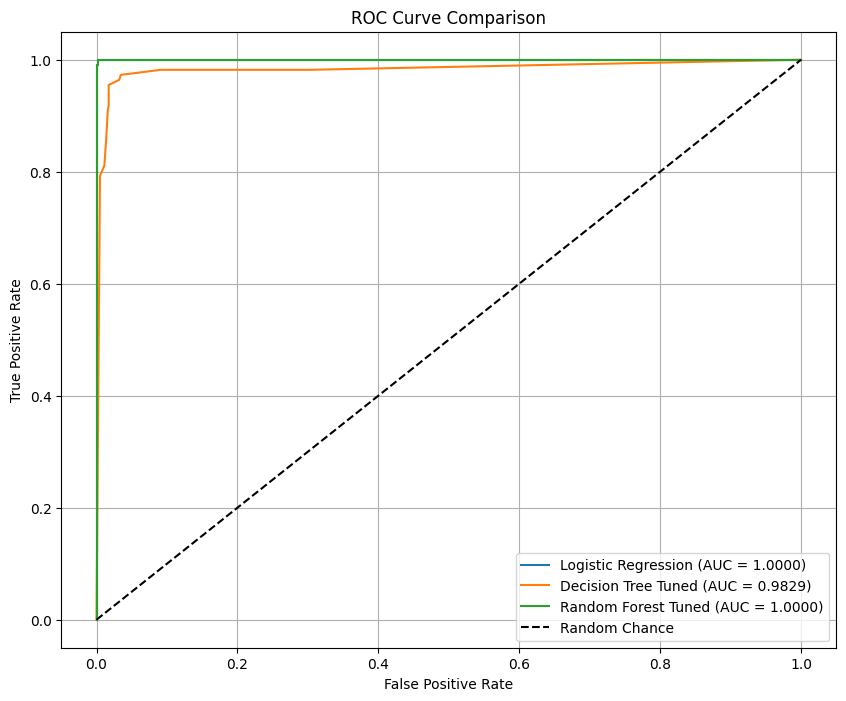

In [9]:
roc_curves = {}
for model_name, model in [("Logistic Regression", log_reg), ("Decision Tree Tuned", dt_model), ("Random Forest Tuned", rf_model)]:
    y_scores = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_curves[model_name] = (fpr, tpr, roc_auc)

plt.figure(figsize=(10, 8))

for model_name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [10]:
for model_name, (_, _, roc_auc) in roc_curves.items():
    print(f"{model_name} AUC-ROC: {roc_auc:.4f}")

Logistic Regression AUC-ROC: 1.0000
Decision Tree Tuned AUC-ROC: 0.9829
Random Forest Tuned AUC-ROC: 1.0000


In [11]:
candidate_models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []
for name, model in candidate_models.items():
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    y_score = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "False Negatives": fn,
        "Recall (minority=1)": recall_score(y_test, y_pred, pos_label=1),
        "AUC-ROC": roc_auc_score(y_test, y_score),
    })

final_results = pd.DataFrame(results).set_index("Model")
final_results = final_results.sort_values(["False Negatives", "Recall (minority=1)"], ascending=[True, False])

print(final_results)

best_final_model_name = final_results.index[0]
best_final_model = candidate_models[best_final_model_name]

print("\nSelected final model based on minimizing false negatives:")
print(best_final_model_name)


                     False Negatives  Recall (minority=1)   AUC-ROC
Model                                                              
Logistic Regression                2             0.981982  0.999978
Random Forest                      3             0.972973  0.999955
Decision Tree                      9             0.918919  0.982945

Selected final model based on minimizing false negatives:
Logistic Regression


---

## 🧾 Part H: Final Analysis & Reporting

26. Prepare a final report including:
   - Best classification model and justification
   - Impact of imbalance handling techniques
   - Comparison of performance metrics
   - Business interpretation of false positives and false negatives

27. Submit:
   - Source code / Jupyter Notebook
   - Evaluation tables and plots
   - Final conclusions and recommendations

The Summary Report is in the file named [`summary-report.pdf`](./summary-report.pdf) in the main directory.

---